# Визуализация графа связей между новостями (структурный анализ)

Этот ноутбук создает визуализацию графа связей между новостными сообщениями на основе их структурных характеристик в сети, без опоры на метрики вирусности.


In [18]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
# === Импорты и настройки ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# Пути к данным
DATA_DIR = str(ROOT / "data")
ART_DIR = str(ROOT / "artifacts")

print("Импорты загружены успешно!")


Импорты загружены успешно!


In [19]:
# === Загрузка данных ===
print("Загрузка данных графа...")

# Загружаем рёбра между сообщениями
edges_msg_msg = pd.read_csv(os.path.join(ART_DIR, "edges_msg_msg.csv"))
print(f"Рёбер между сообщениями: {len(edges_msg_msg):,}")

# Загружаем рёбра канал -> сообщение
edges_ch_msg = pd.read_csv(os.path.join(ART_DIR, "edges_ch_msg.csv"))
print(f"Рёбер канал->сообщение: {len(edges_ch_msg):,}")

# Загружаем графовые признаки
graph_features = pd.read_csv(os.path.join(ART_DIR, "graph_features.csv"))
print(f"Графовых признаков: {len(graph_features):,}")

# Загружаем сообщения (только нужные колонки для экономии памяти)
print("Загрузка сообщений (это может занять время)...")
messages = pd.read_csv(
    os.path.join(DATA_DIR, "messages_with_reactions.csv"),
    usecols=['id', 'message', 'id_channel', 'date', 'text_len', 'word_count']
)
print(f"Сообщений загружено: {len(messages):,}")

print("\n✓ Все данные загружены!")


Загрузка данных графа...
Рёбер между сообщениями: 85,984
Рёбер канал->сообщение: 123,273
Графовых признаков: 123,273
Загрузка сообщений (это может занять время)...
Сообщений загружено: 7,026,594

✓ Все данные загружены!


## Подготовка данных для визуализации

Выберем репрезентативную выборку новостей на основе **структурных характеристик графа**:

1. **Хабы** - сообщения с высокой степенью связности (msg_sim_degree)
2. **Кластерные центры** - сообщения с высоким коэффициентом кластеризации (msg_clustering)
3. Добавим их соседей для полноты картины


In [29]:
# === Подготовка данных ===

# Объединяем данные
messages_full = messages.merge(
    graph_features[['id', 'msg_sim_degree', 'msg_clustering']],
    on='id',
    how='left'
)

# Заполняем пропуски
messages_full['msg_sim_degree'] = messages_full['msg_sim_degree'].fillna(0)
messages_full['msg_clustering'] = messages_full['msg_clustering'].fillna(0)

# Вычисляем процентили для определения порогов
degree_p90 = messages_full['msg_sim_degree'].quantile(0.90)
clustering_p90 = messages_full['msg_clustering'].quantile(0.90)

print(f"Всего сообщений с признаками: {len(messages_full):,}")
print(f"\n📊 Статистика структурных признаков:")
print(f"  • Средняя степень связности: {messages_full['msg_sim_degree'].mean():.2f}")
print(f"  • Максимальная степень: {messages_full['msg_sim_degree'].max():.0f}")
print(f"  • 90-й процентиль степени: {degree_p90:.2f}")
print(f"\n  • Средний коэффициент кластеризации: {messages_full['msg_clustering'].mean():.4f}")
print(f"  • Максимальный коэффициент: {messages_full['msg_clustering'].max():.4f}")
print(f"  • 90-й процентиль кластеризации: {clustering_p90:.4f}")


Всего сообщений с признаками: 7,026,594

📊 Статистика структурных признаков:
  • Средняя степень связности: 0.97
  • Максимальная степень: 131
  • 90-й процентиль степени: 2.00

  • Средний коэффициент кластеризации: 0.0741
  • Максимальный коэффициент: 1.0000
  • 90-й процентиль кластеризации: 0.2857


In [59]:
# === Выбор репрезентативной выборки на основе структурных признаков ===

# Стратегия: возьмем узлы с разными структурными ролями
TOP_DEGREE_COUNT = 60  # топ по степени связности (хабы) - увеличено
TOP_CLUSTERING_COUNT = 50  # топ по кластеризации (центры кластеров) - увеличено
NEIGHBORS_PER_NODE = 10  # сколько соседей добавить для каждого узла - увеличено

# 1. Хабы - узлы с высокой степенью связности
hub_ids = set(
    messages_full.nlargest(TOP_DEGREE_COUNT, 'msg_sim_degree')['id']
    .astype(str)
)

# 2. Центры кластеров - узлы с высокой кластеризацией И достаточным количеством соседей
# Увеличиваем порог степени, чтобы центры действительно были центрами кластеров
MIN_DEGREE_FOR_CLUSTER_CENTER = 8  # минимум соседей для центра кластера (увеличено для репрезентативности)
MIN_CLUSTERING_FOR_CENTER = 0.3  # минимальный коэффициент кластеризации

cluster_center_ids = set(
    messages_full[
        (messages_full['msg_sim_degree'] >= MIN_DEGREE_FOR_CLUSTER_CENTER) & 
        (messages_full['msg_clustering'] >= MIN_CLUSTERING_FOR_CENTER)
    ].nlargest(TOP_CLUSTERING_COUNT, 'msg_clustering')['id']
    .astype(str)
)

# 3. Добавим узлы со средней степенью связности для полноты картины
medium_degree_ids = set(
    messages_full[
        (messages_full['msg_sim_degree'] >= 2) & 
        (messages_full['msg_sim_degree'] < messages_full['msg_sim_degree'].quantile(0.90))
    ].nlargest(30, 'msg_sim_degree')['id']
    .astype(str)
)

# Объединяем все категории
seed_ids = hub_ids | cluster_center_ids | medium_degree_ids
print(f"Начальных узлов:")
print(f"  • Хабы (высокая степень): {len(hub_ids)}")
print(f"  • Центры кластеров: {len(cluster_center_ids)}")
print(f"  • Средняя степень: {len(medium_degree_ids)}")
print(f"  • Всего уникальных: {len(seed_ids)}")

# 4. Добавляем соседей
edges_str = edges_msg_msg.copy()
edges_str['src'] = edges_str['src'].astype(str)
edges_str['dst'] = edges_str['dst'].astype(str)

# Собираем соседей (больше соседей для лучшей связности)
neighbor_ids = set()
for node_id in seed_ids:
    # Для хабов и центров кластеров добавляем больше соседей
    if node_id in hub_ids or node_id in cluster_center_ids:
        num_neighbors = NEIGHBORS_PER_NODE * 3  # увеличено с 2 до 3
    else:
        num_neighbors = NEIGHBORS_PER_NODE
    
    neighbors = edges_str[edges_str['src'] == node_id]['dst'].head(num_neighbors)
    neighbor_ids.update(neighbors.tolist())
    neighbors_rev = edges_str[edges_str['dst'] == node_id]['src'].head(num_neighbors)
    neighbor_ids.update(neighbors_rev.tolist())

# Финальный набор узлов
all_node_ids = seed_ids | neighbor_ids

# Добавляем мосты между изолированными компонентами
# Если есть изолированные центры кластеров, добавляем их соседей более агрессивно
temp_G = nx.Graph()
temp_G.add_nodes_from(all_node_ids)
temp_edges = edges_str[
    edges_str['src'].isin(all_node_ids) & 
    edges_str['dst'].isin(all_node_ids)
]
temp_G.add_edges_from(temp_edges[['src', 'dst']].values)

components = list(nx.connected_components(temp_G))
if len(components) > 1:
    # Находим компоненты с центрами кластеров
    cluster_component_ids = []
    for comp in components:
        if any(n in cluster_center_ids for n in comp):
            cluster_component_ids.extend(list(comp))
    
    # Добавляем дополнительные связи между компонентами
    for comp in components:
        if any(n in cluster_center_ids for n in comp):
            # Для центров кластеров добавляем больше соседей
            for node_id in comp:
                if node_id in cluster_center_ids:
                    extra_neighbors = edges_str[
                        (edges_str['src'] == node_id) | (edges_str['dst'] == node_id)
                    ]
                    # Добавляем соседей, которые могут связать с другими компонентами
                    for _, row in extra_neighbors.head(20).iterrows():  # увеличено с 10 до 20
                        other_node = row['dst'] if row['src'] == node_id else row['src']
                        if other_node not in all_node_ids:
                            all_node_ids.add(other_node)

print(f"\nВсего узлов после добавления соседей: {len(all_node_ids)}")

# Фильтруем рёбра
subgraph_edges = edges_str[
    edges_str['src'].isin(all_node_ids) & 
    edges_str['dst'].isin(all_node_ids)
].copy()

print(f"Рёбер в подграфе: {len(subgraph_edges):,}")
print(f"Узлов в подграфе: {len(all_node_ids)}")


Начальных узлов:
  • Хабы (высокая степень): 11
  • Центры кластеров: 1
  • Средняя степень: 0
  • Всего уникальных: 12

Всего узлов после добавления соседей: 132
Рёбер в подграфе: 1,395
Узлов в подграфе: 132


## Создание графа и визуализация


In [60]:
# === Создание графа ===
G = nx.Graph()

# Добавляем узлы с атрибутами
node_data = messages_full[messages_full['id'].astype(str).isin(all_node_ids)].copy()
node_data['id'] = node_data['id'].astype(str)

for _, row in node_data.iterrows():
    G.add_node(
        row['id'],
        degree=row['msg_sim_degree'],
        clustering=row['msg_clustering'],
        text_len=row.get('text_len', 0),
        message=row.get('message', '')[:100] if pd.notna(row.get('message')) else ''  # первые 100 символов
    )

# Добавляем рёбра с весами (cosine similarity)
for _, row in subgraph_edges.iterrows():
    G.add_edge(
        row['src'],
        row['dst'],
        weight=row['cosine'],
        cosine=row['cosine']
    )

print(f"Граф создан:")
print(f"  Узлов: {G.number_of_nodes()}")
print(f"  Рёбер: {G.number_of_edges()}")
print(f"  Плотность: {nx.density(G):.4f}")


Граф создан:
  Узлов: 132
  Рёбер: 1395
  Плотность: 0.1613


In [61]:
# === Вычисление дополнительных метрик центральности ===

print("Вычисление метрик центральности...")

# Degree centrality (уже есть, но нормализуем)
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality (важность узла как "моста")
betweenness = nx.betweenness_centrality(G, k=min(100, G.number_of_nodes()))

# Closeness centrality (близость ко всем узлам)
closeness = nx.closeness_centrality(G)

# Eigenvector centrality (важность с учетом важности соседей)
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=100)
except:
    eigenvector = {n: 0 for n in G.nodes()}

# Добавляем метрики к узлам
for node in G.nodes():
    G.nodes[node]['degree_cent'] = degree_centrality.get(node, 0)
    G.nodes[node]['betweenness'] = betweenness.get(node, 0)
    G.nodes[node]['closeness'] = closeness.get(node, 0)
    G.nodes[node]['eigenvector'] = eigenvector.get(node, 0)

print("✓ Метрики центральности вычислены")


Вычисление метрик центральности...
✓ Метрики центральности вычислены


In [62]:
# === Вычисление позиций узлов ===
# Используем spring layout для красивого расположения
print("Вычисление позиций узлов (это может занять время)...")

# Если граф имеет несколько компонент, используем более агрессивный layout
components = list(nx.connected_components(G))
if len(components) > 1:
    # Для лучшей визуализации используем более плотный layout
    pos = nx.spring_layout(
        G, 
        k=1.2,  # меньше расстояние для лучшей связности
        iterations=150,
        seed=42
    )
else:
    pos = nx.spring_layout(
        G, 
        k=1.5,
        iterations=100,
        seed=42
    )
print("✓ Позиции вычислены")


Вычисление позиций узлов (это может занять время)...
✓ Позиции вычислены


Категории узлов в подграфе:
  • Супер-узлы (красные): 0
  • Хабы (оранжевые): 11
  • Центры кластеров (фиолетовые): 1
  • Обычные (синие): 120


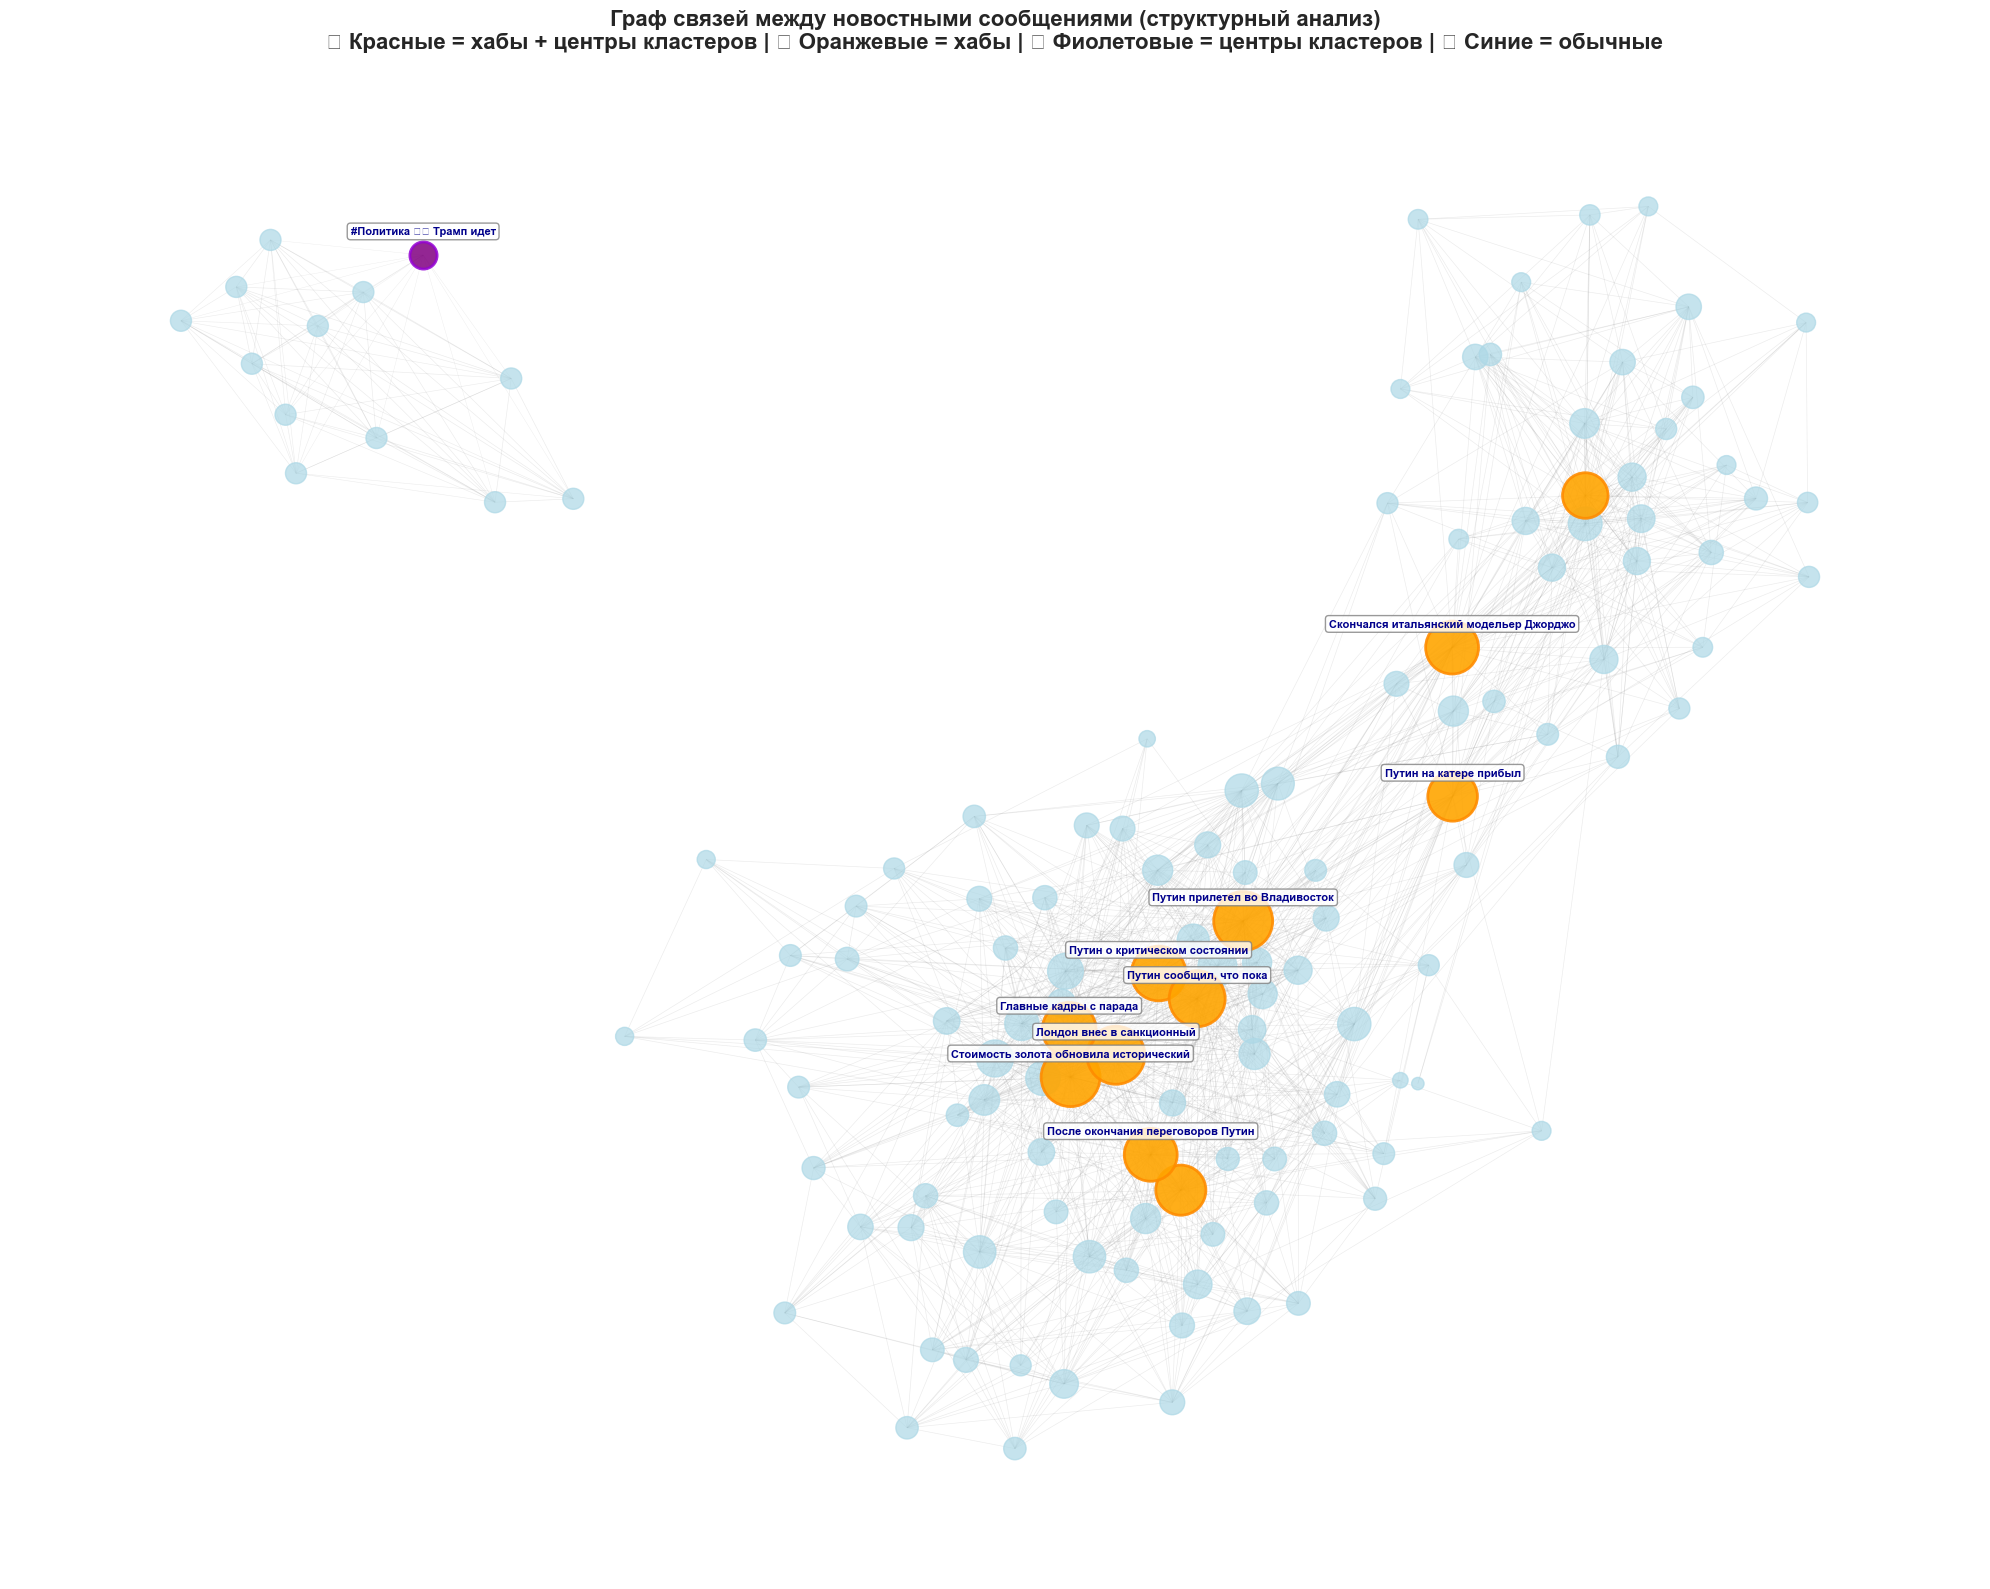

✓ Граф визуализирован!


In [63]:
# === Создание красивой визуализации на основе структурных признаков ===

fig, ax = plt.subplots(figsize=(20, 16))

# Разделяем узлы на категории на основе структурных признаков
# Используем локальные пороги для подграфа, а не глобальные
local_degrees = [G.degree(n) for n in G.nodes()]
local_clustering = [G.nodes[n].get('clustering', 0) for n in G.nodes()]

if local_degrees:
    local_degree_p75 = np.percentile(local_degrees, 75)
else:
    local_degree_p75 = degree_p90

if local_clustering:
    local_clustering_p75 = np.percentile([c for c in local_clustering if c > 0], 75) if any(c > 0 for c in local_clustering) else clustering_p90
else:
    local_clustering_p75 = clustering_p90

hub_nodes = [n for n in G.nodes() 
             if G.degree(n) >= max(3, local_degree_p75) and n in hub_ids]

# Для центров кластеров требуем больше соседей в самом графе, чтобы они были действительно центрами
MIN_CLUSTER_CENTER_DEGREE_IN_GRAPH = 6  # минимум соседей в графе для центра кластера
cluster_nodes = [n for n in G.nodes() 
                 if (G.degree(n) >= MIN_CLUSTER_CENTER_DEGREE_IN_GRAPH) and
                    (G.nodes[n].get('clustering', 0) >= max(0.3, local_clustering_p75)) and 
                    (n in cluster_center_ids)]

# Супер-узлы: узлы, которые являются и хабами, и центрами кластеров
super_nodes = [n for n in hub_nodes if n in cluster_nodes]

# Узлы могут быть в нескольких категориях, создаем приоритет
high_importance_nodes = list(set(hub_nodes) | set(cluster_nodes))
regular_nodes = [n for n in G.nodes() if n not in high_importance_nodes]

print(f"Категории узлов в подграфе:")
print(f"  • Супер-узлы (красные): {len(super_nodes)}")
print(f"  • Хабы (оранжевые): {len(hub_nodes)}")
print(f"  • Центры кластеров (фиолетовые): {len(cluster_nodes)}")
print(f"  • Обычные (синие): {len(regular_nodes)}")

# Рисуем рёбра (сначала, чтобы они были под узлами)
edges = G.edges()
edge_weights = [G[u][v].get('weight', 0.5) for u, v in edges]
nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    width=[w * 0.5 for w in edge_weights],  # толщина по весу
    alpha=0.15,
    edge_color='gray',
    ax=ax
)

# Рисуем обычные узлы
if regular_nodes:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=regular_nodes,
        node_color='lightblue',
        node_size=[G.degree(n) * 15 + 50 for n in regular_nodes],
        alpha=0.7,  # Увеличена непрозрачность
        ax=ax
    )

# Рисуем центры кластеров (фиолетовые) - только те, что не являются хабами
cluster_only = [n for n in cluster_nodes if n not in hub_nodes]
if cluster_only:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=cluster_only,
        node_color='purple',
        node_size=[G.degree(n) * 22 + 120 for n in cluster_only],
        alpha=0.85,
        ax=ax,
        edgecolors='darkviolet',
        linewidths=2
    )

# Рисуем хабы (оранжевые) - только те, что не являются супер-узлами
hub_only = [n for n in hub_nodes if n not in super_nodes]
if hub_only:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=hub_only,
        node_color='orange',
        node_size=[G.degree(n) * 25 + 150 for n in hub_only],
        alpha=0.9,
        ax=ax,
        edgecolors='darkorange',
        linewidths=2
    )

# Узлы, которые являются и хабами, и центрами кластеров (красные) - самые важные
if super_nodes:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=super_nodes,
        node_color='red',
        node_size=[G.degree(n) * 30 + 200 for n in super_nodes],
        alpha=0.95,
        ax=ax,
        edgecolors='darkred',
        linewidths=3
    )

# Подписи для важных узлов
labels_to_show = {}
# Показываем топ узлы по разным метрикам
top_by_degree = sorted(hub_nodes, key=lambda n: G.degree(n), reverse=True)[:8]
top_by_clustering = sorted(cluster_nodes, key=lambda n: G.nodes[n].get('clustering', 0), reverse=True)[:5]
top_by_betweenness = sorted(G.nodes(), key=lambda n: G.nodes[n].get('betweenness', 0), reverse=True)[:5]

for n in list(set(top_by_degree + top_by_clustering + top_by_betweenness))[:15]:
    node_attrs = G.nodes[n]
    message_text = node_attrs.get('message', '')
    if message_text:
        # Берем первые слова сообщения
        short_text = ' '.join(message_text.split()[:4])
        labels_to_show[n] = short_text
    else:
        labels_to_show[n] = f"ID: {n[:8]}"

if labels_to_show:
    # Создаем смещенные позиции для подписей (прямо над узлами)
    label_pos = {}
    offset = 0.02  # вертикальное смещение вверх от узла
    for node, label in labels_to_show.items():
        x, y = pos[node]
        # Смещаем только вверх, без горизонтального смещения
        label_pos[node] = (x, y + offset)
    
    nx.draw_networkx_labels(
        G, label_pos,
        labels=labels_to_show,
        font_size=8,
        font_color='darkblue',
        font_weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
        horizontalalignment='center',
        verticalalignment='bottom',
        ax=ax
    )

ax.set_title(
    'Граф связей между новостными сообщениями (структурный анализ)\n'
    '🔴 Красные = хабы + центры кластеров | 🟠 Оранжевые = хабы | 🟣 Фиолетовые = центры кластеров | 🔵 Синие = обычные',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

print("✓ Граф визуализирован!")


## Статистика и анализ графа


In [64]:
# === Статистика графа ===

print("=" * 70)
print("СТАТИСТИКА ГРАФА (СТРУКТУРНЫЙ АНАЛИЗ)")
print("=" * 70)

print(f"\n📊 Общая информация:")
print(f"  • Узлов: {G.number_of_nodes()}")
print(f"  • Рёбер: {G.number_of_edges()}")
print(f"  • Плотность графа: {nx.density(G):.4f}")
print(f"  • Средняя степень узла: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# Компоненты связности
components = list(nx.connected_components(G))
print(f"\n🔗 Компоненты связности:")
print(f"  • Количество компонент: {len(components)}")
if components:
    largest_comp = max(components, key=len)
    print(f"  • Размер наибольшей компоненты: {len(largest_comp)}")
    print(f"  • Доля узлов в наибольшей компоненте: {len(largest_comp) / G.number_of_nodes() * 100:.1f}%")

# Структурные категории узлов
print(f"\n🏗️ Структурные категории узлов:")
print(f"  • Хабы (высокая степень): {len(hub_nodes)}")
print(f"  • Центры кластеров: {len(cluster_nodes)}")
print(f"  • Супер-узлы (хабы + центры): {len(super_nodes)}")
print(f"  • Обычные узлы: {len(regular_nodes)}")

# Статистика по категориям
if hub_nodes:
    hub_degrees = [G.degree(n) for n in hub_nodes]
    hub_clustering = [G.nodes[n].get('clustering', 0) for n in hub_nodes]
    print(f"\n⭐ Хабы:")
    print(f"  • Средняя степень: {np.mean(hub_degrees):.2f}")
    print(f"  • Средний коэффициент кластеризации: {np.mean(hub_clustering):.4f}")

if cluster_nodes:
    cluster_degrees = [G.degree(n) for n in cluster_nodes]
    cluster_clustering = [G.nodes[n].get('clustering', 0) for n in cluster_nodes]
    print(f"\n🟣 Центры кластеров:")
    print(f"  • Средняя степень: {np.mean(cluster_degrees):.2f}")
    print(f"  • Средний коэффициент кластеризации: {np.mean(cluster_clustering):.4f}")

# Топ узлы по разным метрикам
degrees = dict(G.degree())
top_5_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n⭐ Топ-5 узлов по степени связности:")
for node_id, deg in top_5_degrees:
    node_attrs = G.nodes[node_id]
    categories = []
    if node_id in hub_nodes:
        categories.append("ХАБ")
    if node_id in cluster_nodes:
        categories.append("КЛАСТЕР")
    if node_id in important_ch_nodes:
        categories.append("КАНАЛ")
    cat_str = " | ".join(categories) if categories else "обычный"
    print(f"  • {node_id[:12]}... | Степень: {deg} | {cat_str}")

top_5_betweenness = sorted(
    [(n, G.nodes[n].get('betweenness', 0)) for n in G.nodes()],
    key=lambda x: x[1], reverse=True
)[:5]
print(f"\n🌉 Топ-5 узлов по betweenness centrality (мосты):")
for node_id, betw in top_5_betweenness:
    print(f"  • {node_id[:12]}... | Betweenness: {betw:.4f}")

# Средний вес рёбер
edge_weights_list = [G[u][v].get('cosine', 0) for u, v in G.edges()]
print(f"\n🔗 Рёбра:")
print(f"  • Средняя косинусная близость: {np.mean(edge_weights_list):.3f}")
print(f"  • Медианная близость: {np.median(edge_weights_list):.3f}")
print(f"  • Максимальная близость: {np.max(edge_weights_list):.3f}")

print("\n" + "=" * 70)


СТАТИСТИКА ГРАФА (СТРУКТУРНЫЙ АНАЛИЗ)

📊 Общая информация:
  • Узлов: 132
  • Рёбер: 1395
  • Плотность графа: 0.1613
  • Средняя степень узла: 21.14

🔗 Компоненты связности:
  • Количество компонент: 2
  • Размер наибольшей компоненты: 119
  • Доля узлов в наибольшей компоненте: 90.2%

🏗️ Структурные категории узлов:
  • Хабы (высокая степень): 11
  • Центры кластеров: 1
  • Супер-узлы (хабы + центры): 0
  • Обычные узлы: 120

⭐ Хабы:
  • Средняя степень: 54.27
  • Средний коэффициент кластеризации: 0.1717

🟣 Центры кластеров:
  • Средняя степень: 12.00
  • Средний коэффициент кластеризации: 1.0000

⭐ Топ-5 узлов по степени связности:
  • cdc1b9e9-596... | Степень: 66 | ХАБ
  • 7fd38345-162... | Степень: 66 | ХАБ
  • a614c6db-219... | Степень: 64 | ХАБ
  • 3c85f10c-ea1... | Степень: 59 | ХАБ
  • 6b6f1cea-1fb... | Степень: 56 | ХАБ

🌉 Топ-5 узлов по betweenness centrality (мосты):
  • 31af8278-178... | Betweenness: 0.1048
  • 0fe647a0-908... | Betweenness: 0.0797
  • cdc1b9e9-596... | 

## Подробное описание графа

### Структура графа

Граф представляет собой сеть связей между новостными сообщениями из Telegram-каналов, где связи основаны на **семантической близости** и **временной близости** сообщений.

**Узлы (Nodes):**
- Каждый узел = одно новостное сообщение
- Узлы характеризуются структурными признаками:
  - **Степень связности** (`msg_sim_degree`): количество похожих сообщений (количество соседей)
  - **Коэффициент кластеризации** (`msg_clustering`): мера локальной плотности связей (насколько соседи связаны друг с другом)

**Рёбра (Edges):**
- Связь между двумя сообщениями существует, если:
  - Косинусная близость их векторных представлений > 0.55 (порог θ)
  - Временная близость: сообщения опубликованы в пределах 24 часов друг от друга
- Вес рёбра = косинусная близость (от 0.55 до 1.0)

### Категории узлов в визуализации

На графе узлы разделены на категории по их **структурной роли** в сети:

1. **🔴 Красные узлы** - Супер-узлы (хабы + центры кластеров)
   - Имеют высокую степень связности И высокий коэффициент кластеризации
   - Самые важные структурно: являются и хабами, и центрами плотных кластеров
   - Представляют ключевые темы/события, вокруг которых группируются новости

2. **🟠 Оранжевые узлы** - Хабы (высокая степень связности)
   - Имеют много связей с другими сообщениями
   - Являются "узлами коммуникации" в сети
   - Могут связывать разные темы или быть центрами распространения информации

3. **🟣 Фиолетовые узлы** - Центры кластеров (высокая кластеризация)
   - Находятся в центре плотных групп связанных сообщений
   - Их соседи сильно связаны друг с другом
   - Представляют тематические кластеры новостей

4. **🔵 Синие узлы** - Обычные сообщения
   - Размер узла пропорционален его степени связности
   - Представляют основную массу новостей

**Толщина рёбер** пропорциональна косинусной близости сообщений (чем толще, тем более похожи сообщения).

### Метрики центральности

Граф анализируется с помощью различных метрик центральности:

- **Degree Centrality** - количество прямых связей (степень узла)
- **Betweenness Centrality** - важность узла как "моста" между другими узлами
- **Closeness Centrality** - средняя близость ко всем другим узлам
- **Eigenvector Centrality** - важность с учетом важности соседей

### Интерпретация структурных паттернов

- **Плотные кластеры** - группы семантически близких новостей (одна тема/событие)
  - Высокий коэффициент кластеризации указывает на тематическую группировку
  
- **Хабы** - ключевые новости, связывающие множество других
  - Высокая степень связности может указывать на важные события или популярные темы
  
- **Мосты (high betweenness)** - новости, связывающие разные части сети
  - Могут быть важны для распространения информации между кластерами
  
- **Супер-узлы** - комбинация хаба и центра кластера
  - Самые важные структурно: являются центрами плотных групп И связывают их с остальной сетью

### Использование структурных признаков

Структурные признаки графа используются для анализа:

- **Распространение нарративов**: как новости связываются друг с другом
- **Тематические кластеры**: группы семантически близких сообщений
- **Структурная важность**: какие сообщения играют ключевую роль в сети

Эти признаки помогают понять не только содержание сообщений, но и их позицию и роль в сети связей, что может быть важно для анализа распространения информации и выявления ключевых тем и событий.


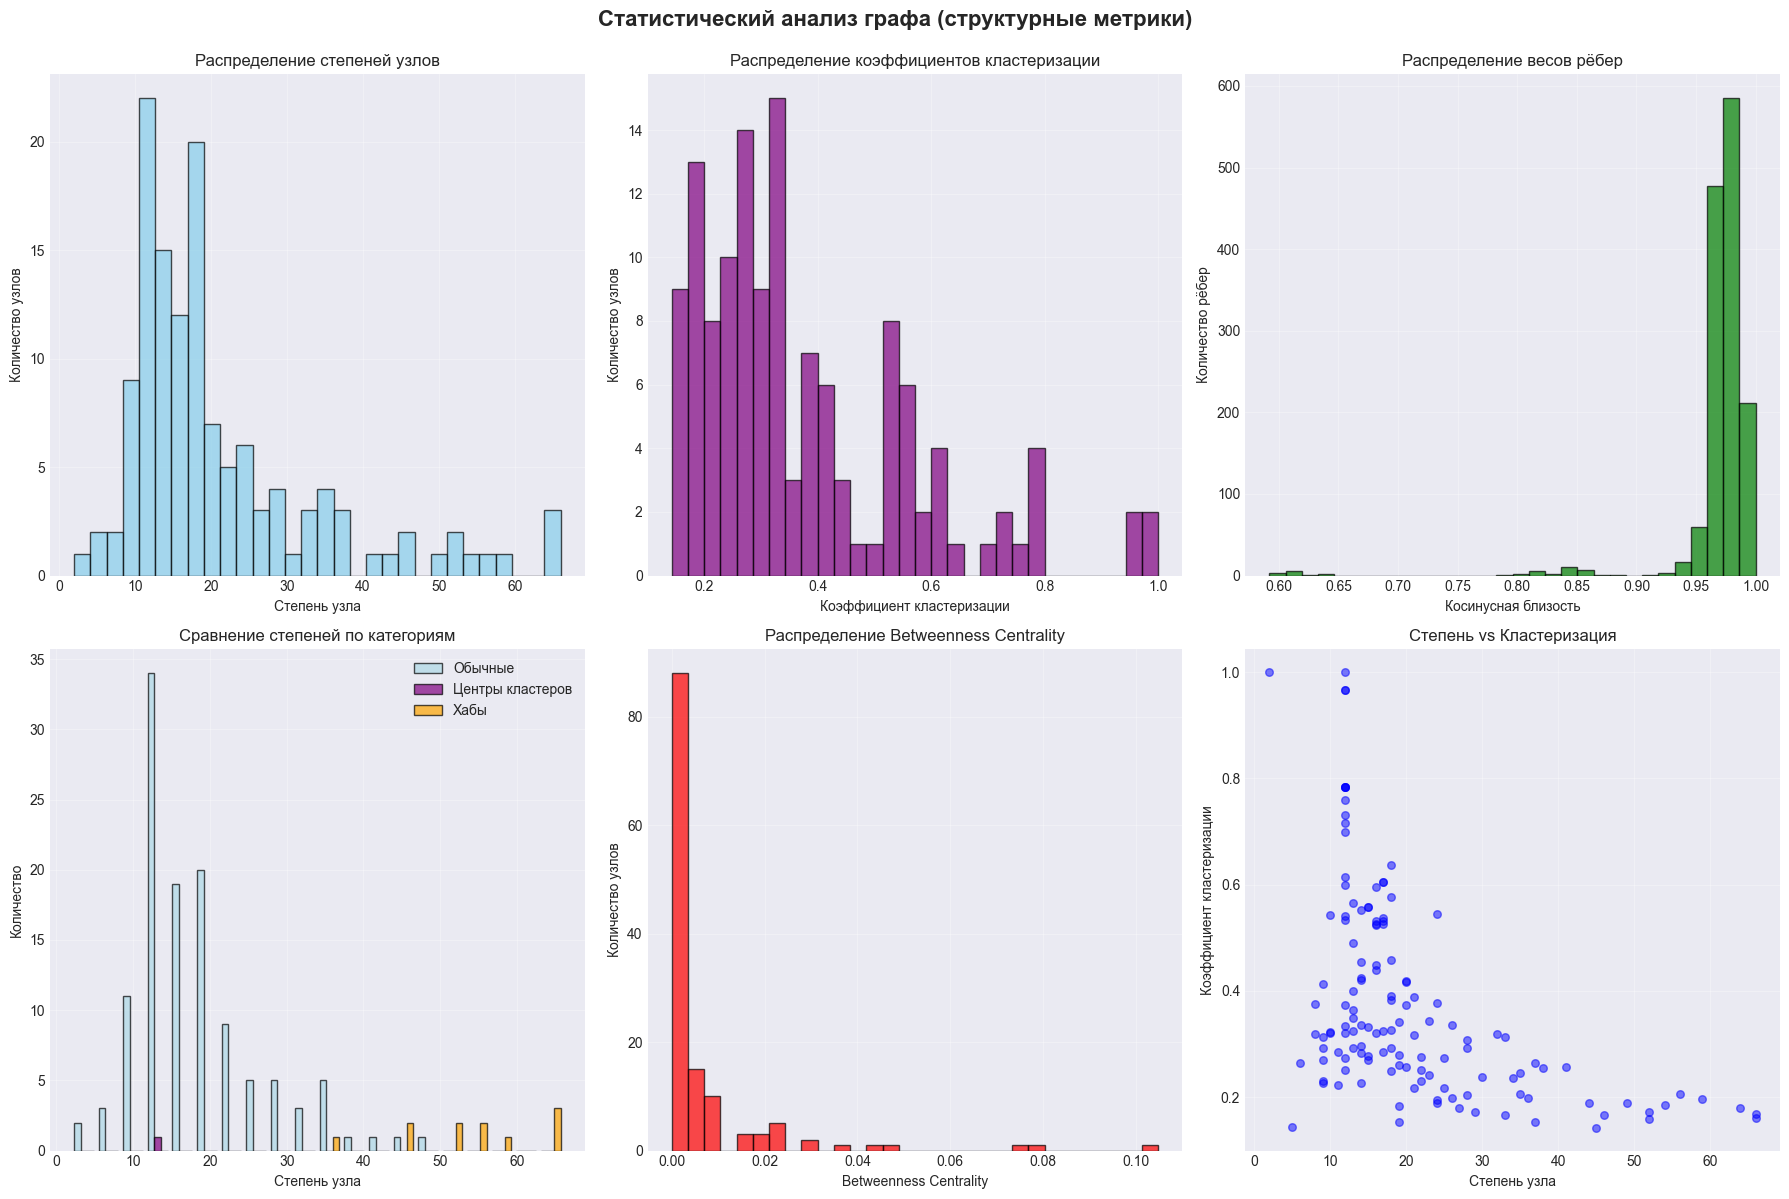

In [65]:
# === Дополнительная визуализация: распределение метрик ===

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Распределение степеней
degrees = [G.degree(n) for n in G.nodes()]
axes[0, 0].hist(degrees, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Степень узла')
axes[0, 0].set_ylabel('Количество узлов')
axes[0, 0].set_title('Распределение степеней узлов')
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение коэффициентов кластеризации
clustering_values = [G.nodes[n].get('clustering', 0) for n in G.nodes()]
axes[0, 1].hist(clustering_values, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Коэффициент кластеризации')
axes[0, 1].set_ylabel('Количество узлов')
axes[0, 1].set_title('Распределение коэффициентов кластеризации')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение весов рёбер
edge_weights_list = [G[u][v].get('cosine', 0) for u, v in G.edges()]
axes[0, 2].hist(edge_weights_list, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Косинусная близость')
axes[0, 2].set_ylabel('Количество рёбер')
axes[0, 2].set_title('Распределение весов рёбер')
axes[0, 2].grid(True, alpha=0.3)

# 4. Сравнение степеней: хабы vs центры кластеров vs обычные
hub_degrees = [G.degree(n) for n in hub_nodes] if hub_nodes else []
cluster_degrees = [G.degree(n) for n in cluster_nodes] if cluster_nodes else []
regular_degrees = [G.degree(n) for n in regular_nodes] if regular_nodes else []

if hub_degrees or cluster_degrees or regular_degrees:
    data_to_plot = []
    labels = []
    colors = []
    if regular_degrees:
        data_to_plot.append(regular_degrees)
        labels.append('Обычные')
        colors.append('lightblue')
    if cluster_degrees:
        data_to_plot.append(cluster_degrees)
        labels.append('Центры кластеров')
        colors.append('purple')
    if hub_degrees:
        data_to_plot.append(hub_degrees)
        labels.append('Хабы')
        colors.append('orange')
    
    axes[1, 0].hist(data_to_plot, bins=20, label=labels, color=colors, alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Степень узла')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].set_title('Сравнение степеней по категориям')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 5. Betweenness centrality
betweenness_values = [G.nodes[n].get('betweenness', 0) for n in G.nodes()]
axes[1, 1].hist(betweenness_values, bins=30, color='red', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Betweenness Centrality')
axes[1, 1].set_ylabel('Количество узлов')
axes[1, 1].set_title('Распределение Betweenness Centrality')
axes[1, 1].grid(True, alpha=0.3)

# 6. Scatter: степень vs кластеризация
degrees_list = [G.degree(n) for n in G.nodes()]
clustering_list = [G.nodes[n].get('clustering', 0) for n in G.nodes()]
axes[1, 2].scatter(degrees_list, clustering_list, alpha=0.5, s=30, color='blue')
axes[1, 2].set_xlabel('Степень узла')
axes[1, 2].set_ylabel('Коэффициент кластеризации')
axes[1, 2].set_title('Степень vs Кластеризация')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Статистический анализ графа (структурные метрики)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Визуализация наибольшей компоненты (119 узлов)...


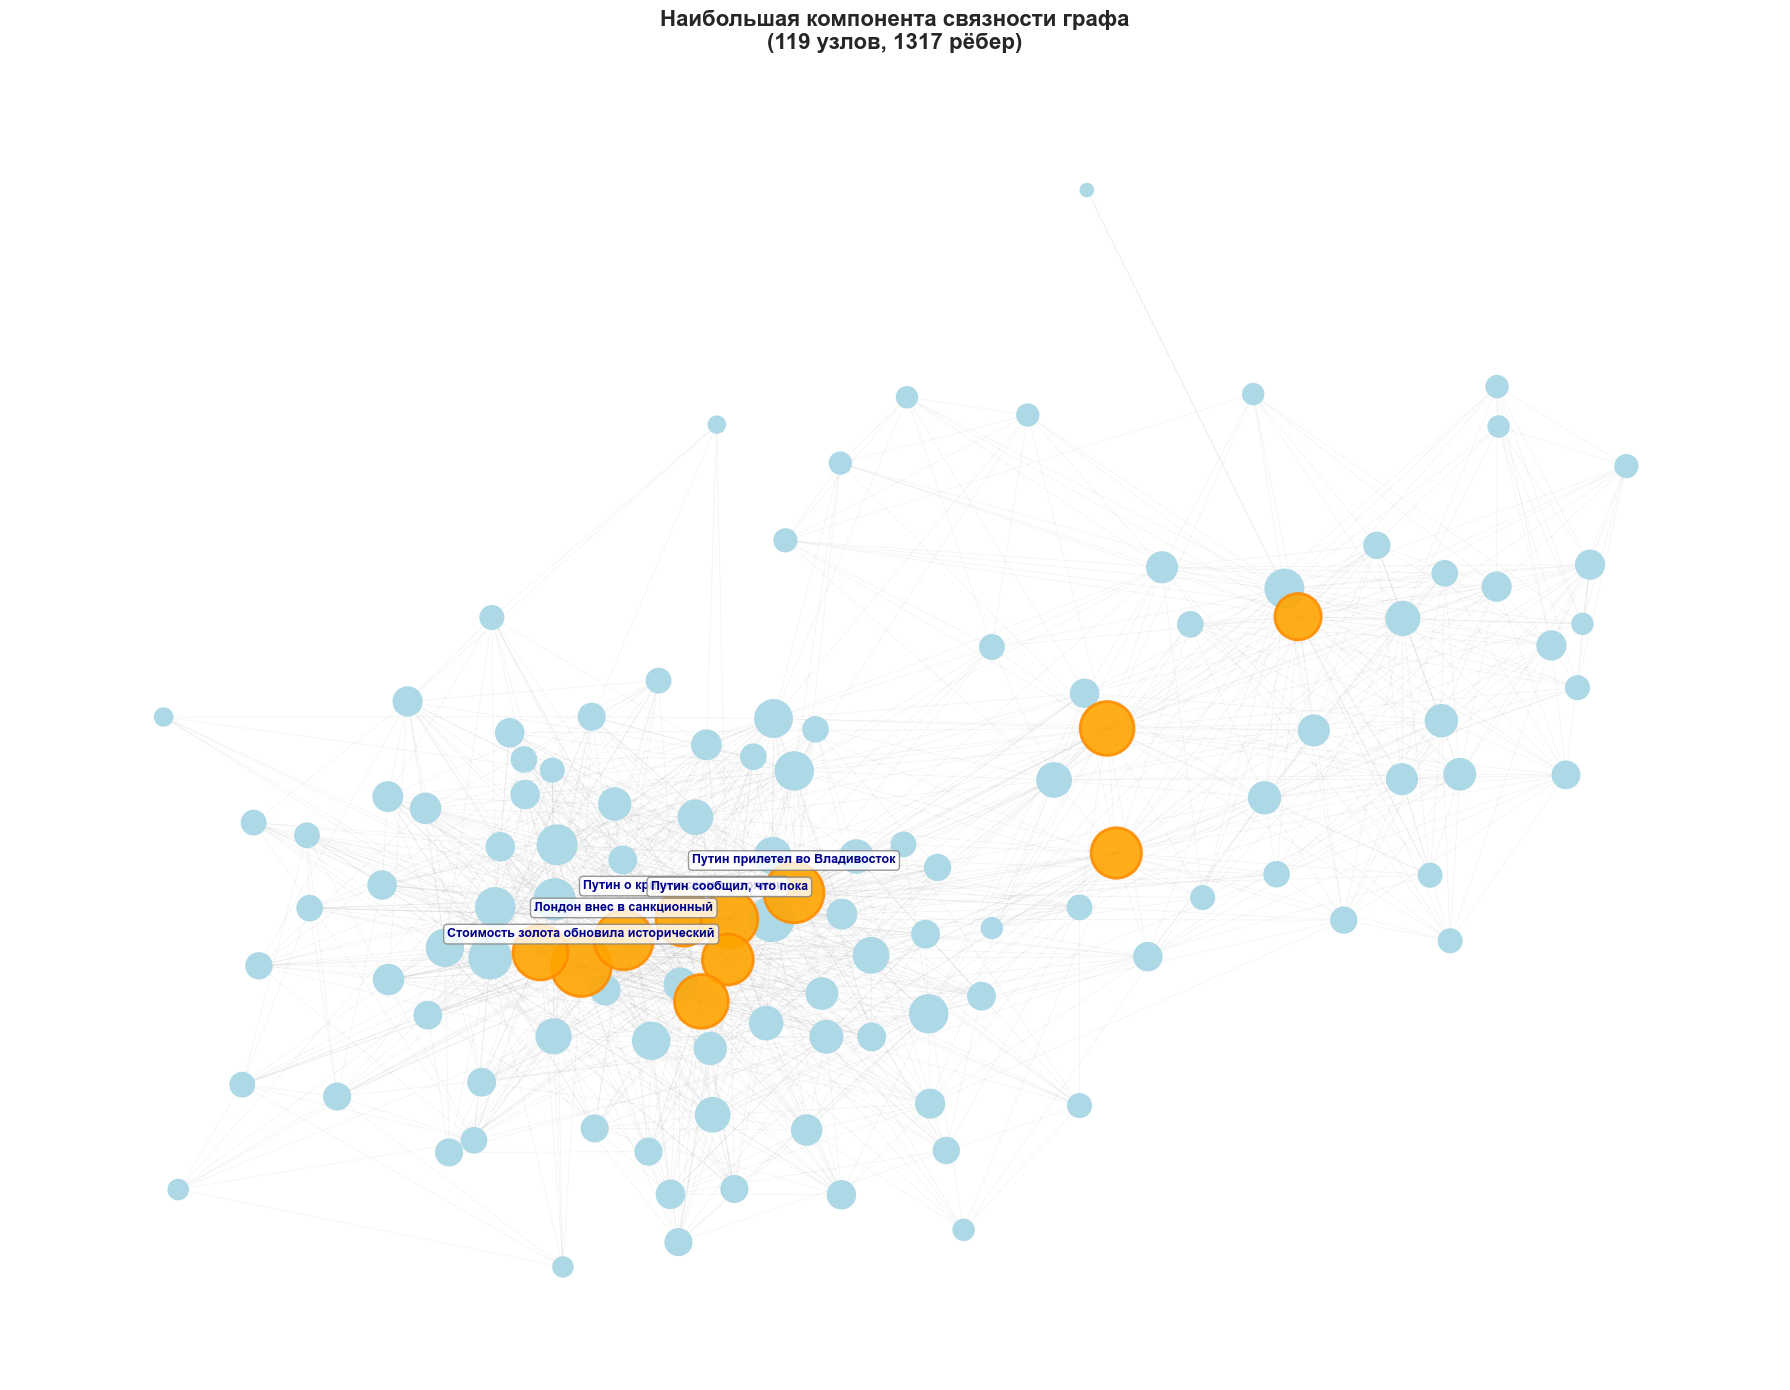

✓ Визуализация наибольшей компоненты завершена


In [66]:
# === Визуализация наибольшей компоненты связности ===

if components:
    largest_component = max(components, key=len)
    G_largest = G.subgraph(largest_component).copy()
    
    print(f"Визуализация наибольшей компоненты ({len(largest_component)} узлов)...")
    
    # Вычисляем позиции для наибольшей компоненты
    pos_largest = nx.spring_layout(G_largest, k=1.2, iterations=100, seed=42)
    
    fig, ax = plt.subplots(figsize=(18, 14))
    
    # Разделяем узлы
    hub_largest = [n for n in hub_nodes if n in largest_component]
    cluster_largest = [n for n in cluster_nodes if n in largest_component]
    super_largest = [n for n in super_nodes if n in largest_component]
    regular_largest = [n for n in regular_nodes if n in largest_component]
    
    # Рисуем рёбра
    nx.draw_networkx_edges(
        G_largest, pos_largest,
        alpha=0.1,
        edge_color='gray',
        width=0.5,
        ax=ax
    )
    
    # Рисуем узлы
    if regular_largest:
        nx.draw_networkx_nodes(
            G_largest, pos_largest,
            nodelist=regular_largest,
            node_color='lightblue',
            node_size=[G_largest.degree(n) * 20 + 50 for n in regular_largest],
            alpha=1,  # Увеличена непрозрачность
            ax=ax
        )
    
    cluster_only_largest = [n for n in cluster_largest if n not in hub_largest]
    if cluster_only_largest:
        nx.draw_networkx_nodes(
            G_largest, pos_largest,
            nodelist=cluster_only_largest,
            node_color='purple',
            node_size=[G_largest.degree(n) * 24 + 120 for n in cluster_only_largest],
            alpha=0.85,
            ax=ax,
            edgecolors='darkviolet',
            linewidths=2
        )
    
    hub_only_largest = [n for n in hub_largest if n not in super_largest]
    if hub_only_largest:
        nx.draw_networkx_nodes(
            G_largest, pos_largest,
            nodelist=hub_only_largest,
            node_color='orange',
            node_size=[G_largest.degree(n) * 26 + 150 for n in hub_only_largest],
            alpha=0.9,
            ax=ax,
            edgecolors='darkorange',
            linewidths=2
        )
    
    if super_largest:
        nx.draw_networkx_nodes(
            G_largest, pos_largest,
            nodelist=super_largest,
            node_color='red',
            node_size=[G_largest.degree(n) * 30 + 200 for n in super_largest],
            alpha=0.95,
            ax=ax,
            edgecolors='darkred',
            linewidths=3
        )
    
    # Подписи для топ узлов
    labels_largest = {}
    top_nodes_largest = (list(super_largest)[:5] + 
                      list(hub_largest)[:5] + 
                      sorted(cluster_largest, key=lambda n: G_largest.nodes[n].get('clustering', 0), reverse=True)[:5])
    
    for n in top_nodes_largest[:15]:
        node_attrs = G_largest.nodes[n]
        message_text = node_attrs.get('message', '')
        if message_text:
            short_text = ' '.join(message_text.split()[:4])
            labels_largest[n] = short_text
        else:
            labels_largest[n] = f"{n[:8]}"
    
    if labels_largest:
        # Создаем смещенные позиции для подписей (прямо над узлами)
        label_pos_largest = {}
        offset = 0.04  # вертикальное смещение вверх от узла
        for node, label in labels_largest.items():
            x, y = pos_largest[node]
            # Смещаем только вверх, без горизонтального смещения
            label_pos_largest[node] = (x, y + offset)
        
        nx.draw_networkx_labels(
            G_largest, label_pos_largest,
            labels=labels_largest,
            font_size=9,
            font_color='darkblue',
            font_weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
            horizontalalignment='center',
            verticalalignment='bottom',
            ax=ax
        )
    
    ax.set_title(
        f'Наибольшая компонента связности графа\n'
        f'({len(largest_component)} узлов, {G_largest.number_of_edges()} рёбер)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("✓ Визуализация наибольшей компоненты завершена")


## Отдельные визуализации: центры кластеров и хабы

Ниже представлены две отдельные визуализации:
1. **Центры кластеров** и узлы вокруг них (с подписями всех узлов)
2. **Хабы** и узлы вокруг них (с увеличенным порогом близости для меньшего количества рёбер и подписями всех хабов)


Создание подграфа для центров кластеров...
Подграф центров кластеров:
  Центров кластеров: 1
  Соседей: 12
  Всего узлов: 13
  Рёбер: 78


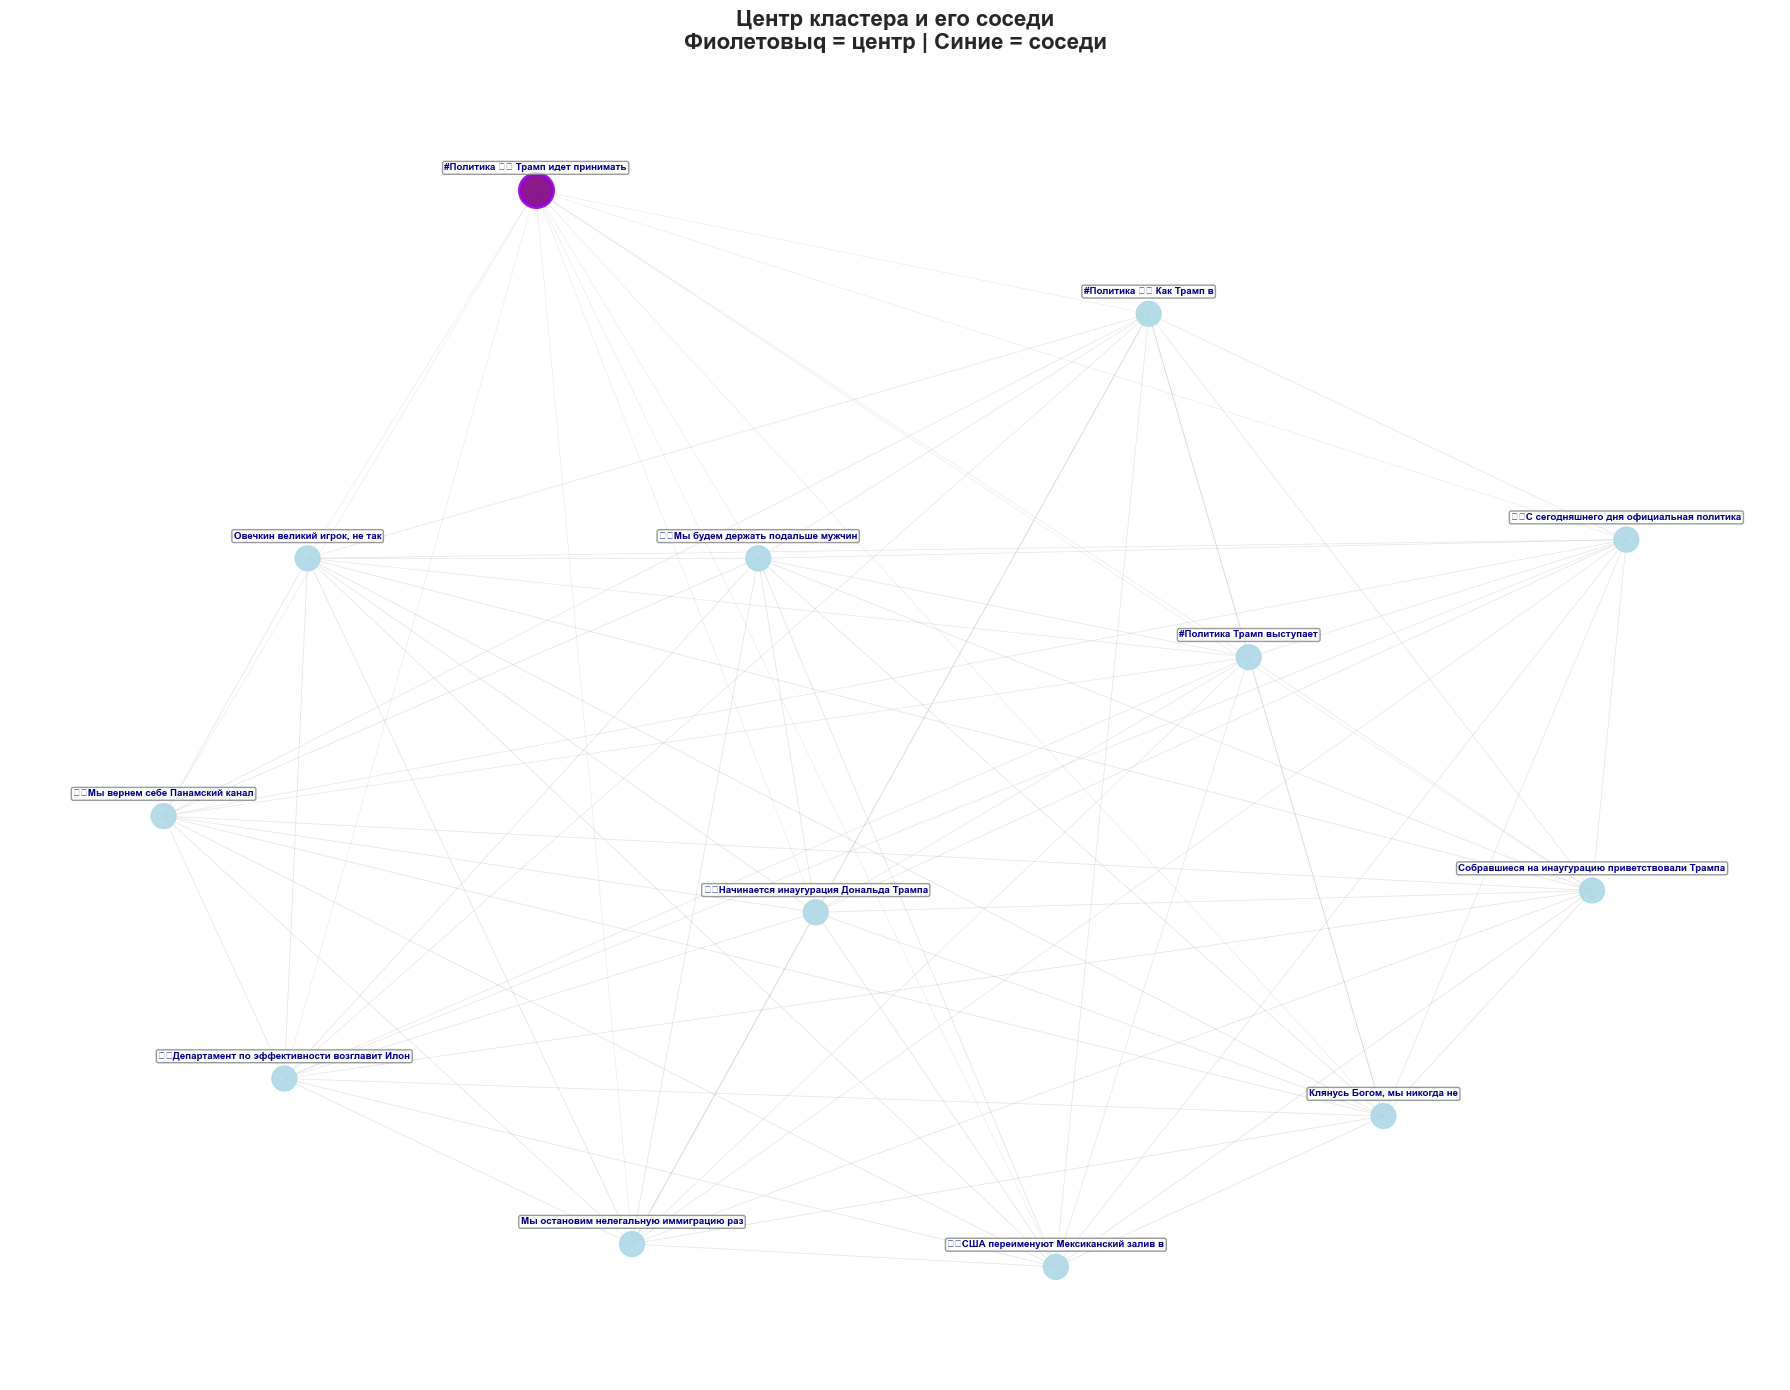

✓ Визуализация центров кластеров завершена!


In [94]:
# === Визуализация центров кластеров и их соседей ===

print("Создание подграфа для центров кластеров...")

# Собираем все узлы, связанные с центрами кластеров
cluster_center_node_ids = set(cluster_nodes)
cluster_neighbor_ids = set()

# Добавляем всех соседей центров кластеров
for center_id in cluster_center_node_ids:
    neighbors = list(G.neighbors(center_id))
    cluster_neighbor_ids.update(neighbors)

# Создаем подграф только с центрами кластеров и их соседями
cluster_subgraph_nodes = cluster_center_node_ids | cluster_neighbor_ids
G_cluster = G.subgraph(cluster_subgraph_nodes).copy()

print(f"Подграф центров кластеров:")
print(f"  Центров кластеров: {len(cluster_center_node_ids)}")
print(f"  Соседей: {len(cluster_neighbor_ids)}")
print(f"  Всего узлов: {G_cluster.number_of_nodes()}")
print(f"  Рёбер: {G_cluster.number_of_edges()}")

# Вычисляем позиции
pos_cluster = nx.spring_layout(G_cluster, k=1.0, iterations=100, seed=42)

# Визуализация
fig, ax = plt.subplots(figsize=(18, 14))

# Рисуем рёбра
edges_cluster = list(G_cluster.edges())
edge_weights_cluster = [G_cluster[u][v].get('weight', 0.5) for u, v in edges_cluster]
nx.draw_networkx_edges(
    G_cluster, pos_cluster,
    edgelist=edges_cluster,
    width=[w * 0.6 for w in edge_weights_cluster],
    alpha=0.2,
    edge_color='gray',
    ax=ax
)

# Разделяем узлы
cluster_nodes_in_subgraph = [n for n in cluster_center_node_ids if n in G_cluster.nodes()]
neighbor_nodes_in_subgraph = [n for n in cluster_neighbor_ids if n in G_cluster.nodes()]

# Рисуем соседей (синие)
if neighbor_nodes_in_subgraph:
    nx.draw_networkx_nodes(
        G_cluster, pos_cluster,
        nodelist=neighbor_nodes_in_subgraph,
        node_color='lightblue',
        node_size=[G_cluster.degree(n) * 20 + 80 for n in neighbor_nodes_in_subgraph],
        alpha=0.9,
        ax=ax
    )

# Рисуем центры кластеров (фиолетовые)
if cluster_nodes_in_subgraph:
    nx.draw_networkx_nodes(
        G_cluster, pos_cluster,
        nodelist=cluster_nodes_in_subgraph,
        node_color='purple',
        node_size=[G_cluster.degree(n) * 30 + 200 for n in cluster_nodes_in_subgraph],
        alpha=0.9,
        ax=ax,
        edgecolors='darkviolet',
        linewidths=3
    )

# Подписи для ВСЕХ узлов
labels_cluster = {}
for n in G_cluster.nodes():
    node_attrs = G_cluster.nodes[n]
    message_text = node_attrs.get('message', '')
    if message_text:
        # Берем первые слова сообщения
        short_text = ' '.join(message_text.split()[:5])
        labels_cluster[n] = short_text
    else:
        labels_cluster[n] = f"ID: {n[:8]}"

if labels_cluster:
    label_pos_cluster = {}
    offset = 0.03
    for node, label in labels_cluster.items():
        x, y = pos_cluster[node]
        label_pos_cluster[node] = (x, y + offset)
    
    nx.draw_networkx_labels(
        G_cluster, label_pos_cluster,
        labels=labels_cluster,
        font_size=7,
        font_color='darkblue',
        font_weight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'),
        horizontalalignment='center',
        verticalalignment='bottom',
        ax=ax
    )

ax.set_title(
    'Центр кластера и его соседи\n'
    'Фиолетовыq = центр | Синие = соседи',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

print("✓ Визуализация центров кластеров завершена!")


Создание подграфа для хабов с увеличенным порогом близости...
Подграф хабов (порог близости 0.975):
  Хабов: 11
  Соседей: 84
  Всего узлов: 84
  Рёбер (после фильтрации): 651


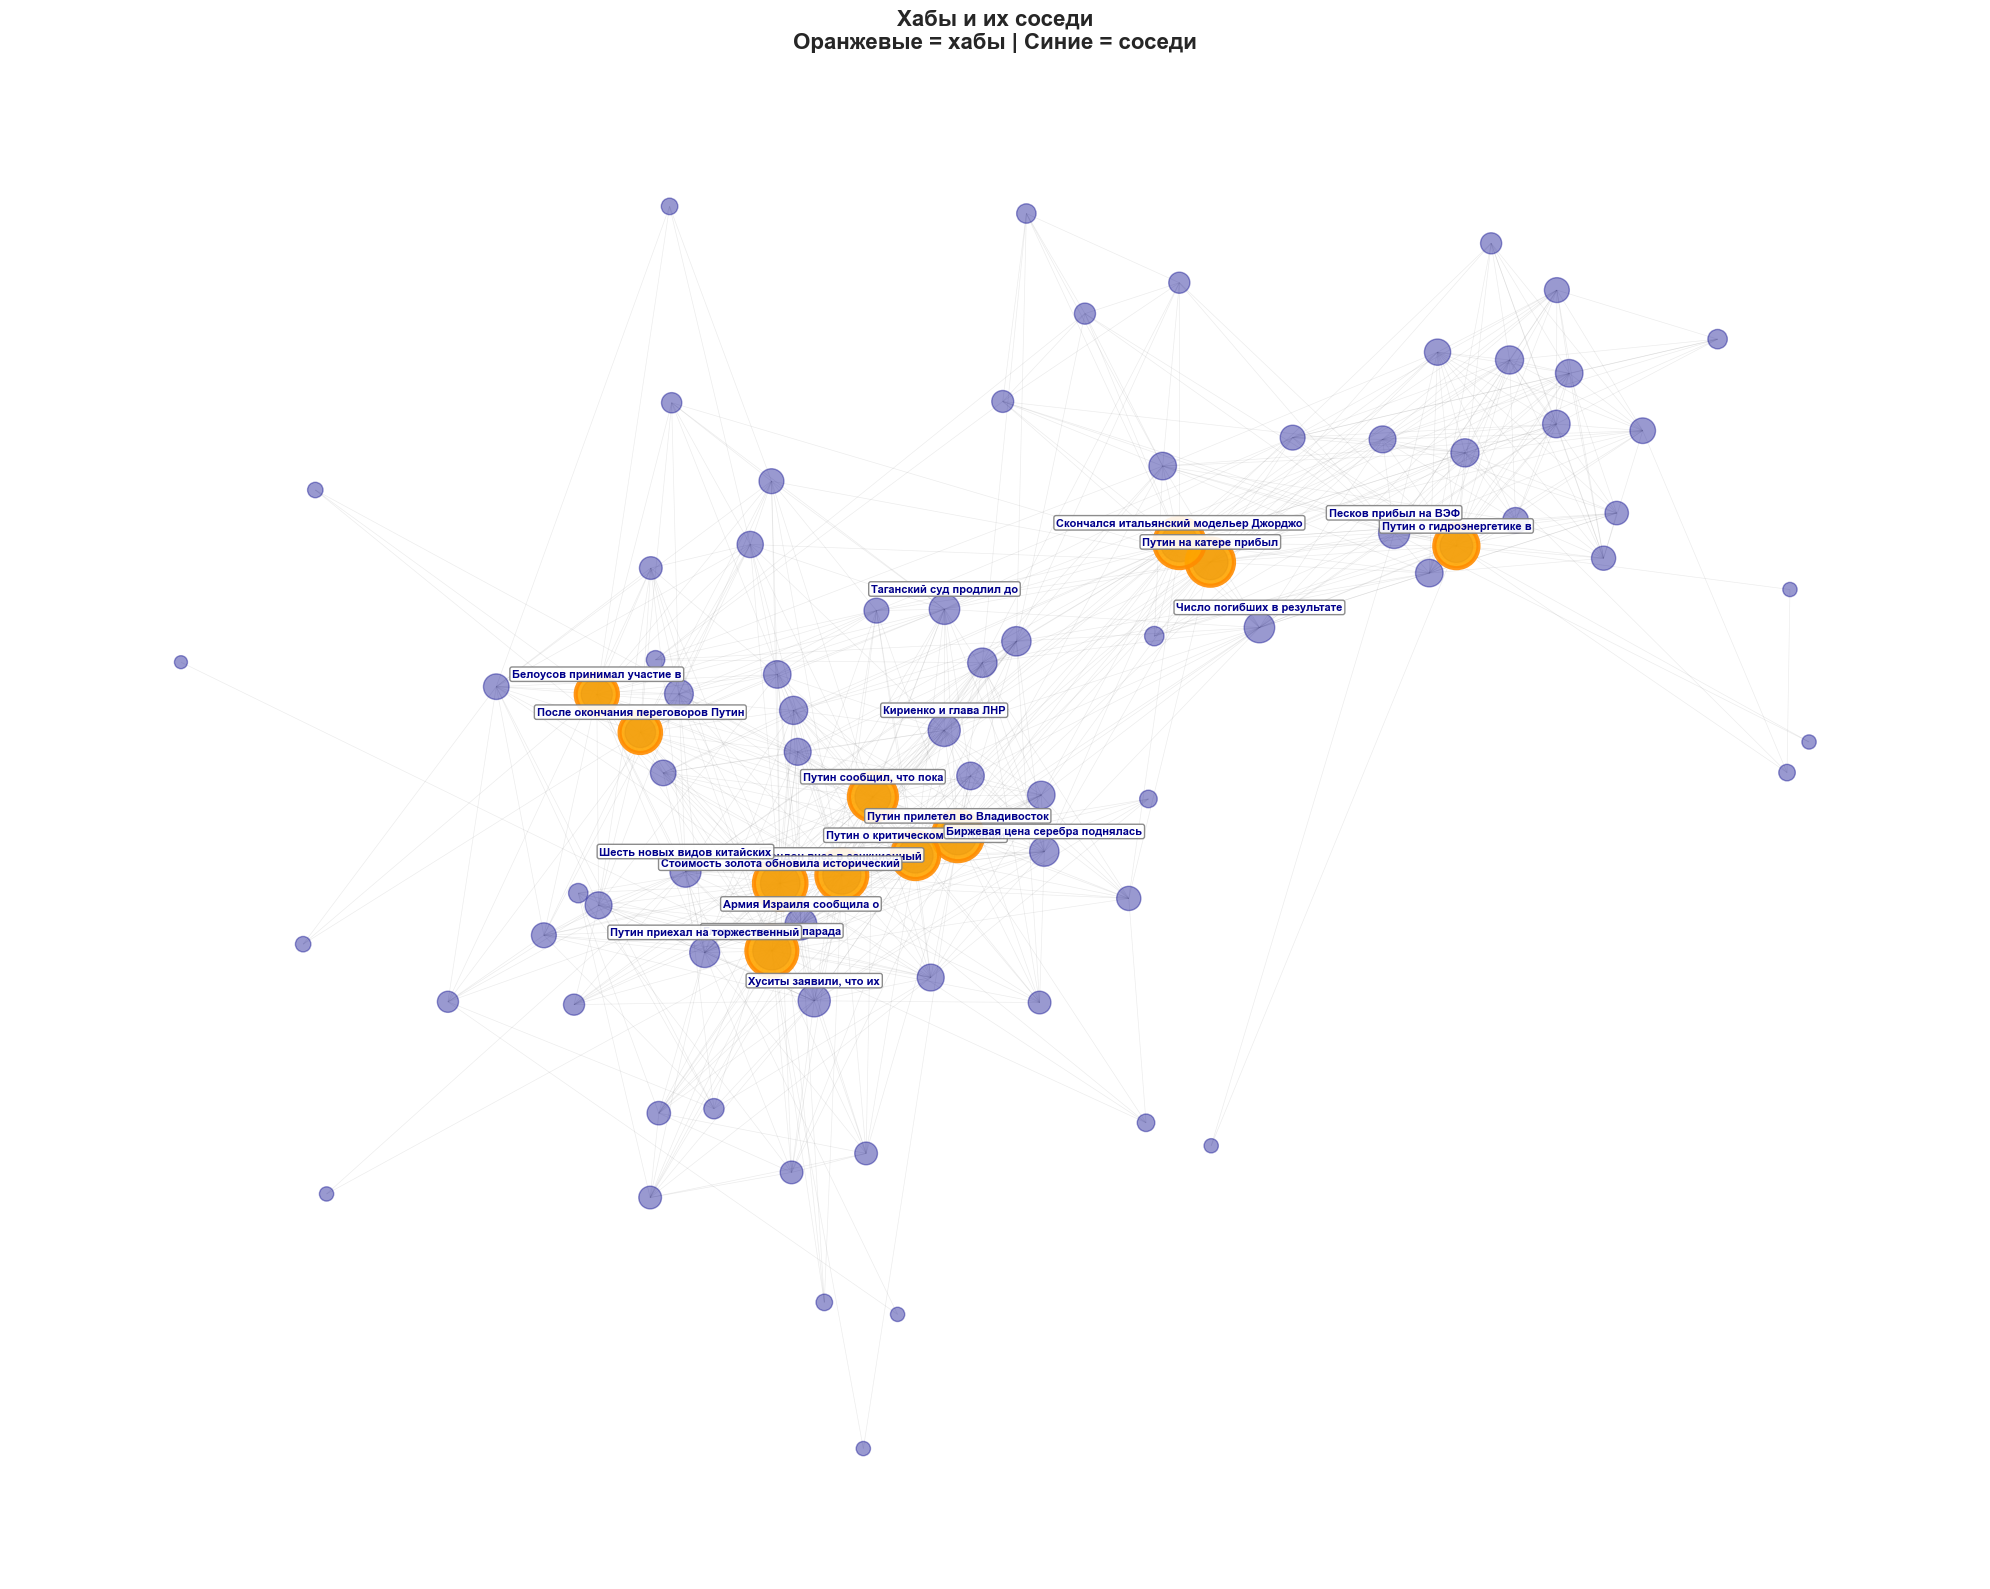

✓ Визуализация хабов завершена!


In [91]:
# === Визуализация хабов и их соседей (с увеличенным порогом близости) ===

print("Создание подграфа для хабов с увеличенным порогом близости...")

# Увеличиваем порог близости для хабов, чтобы рёбер стало меньше
HIGHER_THETA = 0.975  # увеличенный порог (было 0.55)

# Собираем все узлы, связанные с хабами
hub_node_ids = set(hub_nodes)
hub_neighbor_ids = set()

# Фильтруем рёбра с увеличенным порогом близости
edges_hub_filtered = []
for u, v in G.edges():
    if u in hub_node_ids or v in hub_node_ids:
        cosine_sim = G[u][v].get('cosine', 0)
        if cosine_sim >= HIGHER_THETA:
            edges_hub_filtered.append((u, v))
            if u in hub_node_ids:
                hub_neighbor_ids.add(v)
            if v in hub_node_ids:
                hub_neighbor_ids.add(u)

# Создаем подграф только с хабами и их соседями (с фильтрованными рёбрами)
hub_subgraph_nodes = hub_node_ids | hub_neighbor_ids
G_hub = G.subgraph(hub_subgraph_nodes).copy()

# Удаляем рёбра с низкой близостью
edges_to_remove = []
for u, v in G_hub.edges():
    cosine_sim = G_hub[u][v].get('cosine', 0)
    if cosine_sim < HIGHER_THETA:
        edges_to_remove.append((u, v))
G_hub.remove_edges_from(edges_to_remove)

# Удаляем изолированные узлы (которые остались без связей после фильтрации)
isolated_nodes = list(nx.isolates(G_hub))
G_hub.remove_nodes_from(isolated_nodes)

print(f"Подграф хабов (порог близости {HIGHER_THETA}):")
print(f"  Хабов: {len([n for n in hub_node_ids if n in G_hub.nodes()])}")
print(f"  Соседей: {len([n for n in hub_neighbor_ids if n in G_hub.nodes()])}")
print(f"  Всего узлов: {G_hub.number_of_nodes()}")
print(f"  Рёбер (после фильтрации): {G_hub.number_of_edges()}")

# Вычисляем позиции
pos_hub = nx.spring_layout(G_hub, k=1.2, iterations=100, seed=42)

# Визуализация
fig, ax = plt.subplots(figsize=(20, 16))

# Рисуем рёбра
edges_hub = list(G_hub.edges())
edge_weights_hub = [G_hub[u][v].get('weight', 0.5) for u, v in edges_hub]
nx.draw_networkx_edges(
    G_hub, pos_hub,
    edgelist=edges_hub,
    width=[w * 0.5 for w in edge_weights_hub],
    alpha=0.15,
    edge_color='gray',
    ax=ax
)

# Разделяем узлы
hub_nodes_in_subgraph = [n for n in hub_node_ids if n in G_hub.nodes()]
neighbor_hub_nodes = [n for n in hub_neighbor_ids if n in G_hub.nodes()]

# Рисуем соседей (синие)
if neighbor_hub_nodes:
    nx.draw_networkx_nodes(
        G_hub, pos_hub,
        nodelist=neighbor_hub_nodes,
        node_color='darkblue',
        node_size=[G_hub.degree(n) * 18 + 70 for n in neighbor_hub_nodes],
        alpha=0.4,
        ax=ax
    )

# Рисуем хабы (оранжевые)
if hub_nodes_in_subgraph:
    nx.draw_networkx_nodes(
        G_hub, pos_hub,
        nodelist=hub_nodes_in_subgraph,
        node_color='orange',
        node_size=[G_hub.degree(n) * 30 + 200 for n in hub_nodes_in_subgraph],
        alpha=0.9,
        ax=ax,
        edgecolors='darkorange',
        linewidths=3
    )

# Подписи для ВСЕХ хабов и их ближайших соседей
labels_hub = {}
# Подписываем все хабы
for n in hub_nodes_in_subgraph:
    node_attrs = G_hub.nodes[n]
    message_text = node_attrs.get('message', '')
    if message_text:
        short_text = ' '.join(message_text.split()[:5])
        labels_hub[n] = short_text
    else:
        labels_hub[n] = f"ID: {n[:8]}"

# Подписываем соседей хабов (топ по степени)
top_neighbors = sorted(neighbor_hub_nodes, key=lambda n: G_hub.degree(n), reverse=True)[:20]
for n in top_neighbors:
    node_attrs = G_hub.nodes[n]
    message_text = node_attrs.get('message', '')
    if message_text:
        short_text = ' '.join(message_text.split()[:4])
        labels_hub[n] = short_text

if labels_hub:
    label_pos_hub = {}
    offset = 0.02
    for node, label in labels_hub.items():
        x, y = pos_hub[node]
        label_pos_hub[node] = (x, y + offset)
    
    nx.draw_networkx_labels(
        G_hub, label_pos_hub,
        labels=labels_hub,
        font_size=8,
        font_color='darkblue',
        font_weight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='gray'),
        horizontalalignment='center',
        verticalalignment='bottom',
        ax=ax
    )

ax.set_title(
    f'Хабы и их соседи\n'
    'Оранжевые = хабы | Синие = соседи',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

print("✓ Визуализация хабов завершена!")


## Аналитика и описание графов


In [99]:
# === Аналитика графа центров кластеров ===

print("=" * 70)
print("АНАЛИТИКА ГРАФА ЦЕНТРОВ КЛАСТЕРОВ")
print("=" * 70)

print(f"\n Общая статистика:")
print(f"  • Узлов: {G_cluster.number_of_nodes()}")
print(f"  • Рёбер: {G_cluster.number_of_edges()}")
print(f"  • Плотность: {nx.density(G_cluster):.4f}")
print(f"  • Центров кластеров: {len(cluster_nodes_in_subgraph)}")
print(f"  • Соседей: {len(neighbor_nodes_in_subgraph)}")

# Распределение косинусной близости
edge_cosines_cluster = [G_cluster[u][v].get('cosine', 0) for u, v in G_cluster.edges()]
if edge_cosines_cluster:
    print(f"\n Распределение косинусной близости рёбер:")
    print(f"  • Минимум: {min(edge_cosines_cluster):.4f}")
    print(f"  • Максимум: {max(edge_cosines_cluster):.4f}")
    print(f"  • Среднее: {np.mean(edge_cosines_cluster):.4f}")
    print(f"  • Медиана: {np.median(edge_cosines_cluster):.4f}")
    print(f"  • Стандартное отклонение: {np.std(edge_cosines_cluster):.4f}")

# Статистика по центрам кластеров
if cluster_nodes_in_subgraph:
    cluster_degrees = [G_cluster.degree(n) for n in cluster_nodes_in_subgraph]
    cluster_clustering = [G_cluster.nodes[n].get('clustering', 0) for n in cluster_nodes_in_subgraph]
    print(f"\nСтатистика по центрам кластеров:")
    print(f"  • Средняя степень: {np.mean(cluster_degrees):.2f}")
    print(f"  • Медианная степень: {np.median(cluster_degrees):.2f}")
    print(f"  • Средний коэффициент кластеризации: {np.mean(cluster_clustering):.4f}")
    print(f"  • Медианный коэффициент кластеризации: {np.median(cluster_clustering):.4f}")

# Компоненты связности
components_cluster = list(nx.connected_components(G_cluster))
print(f"\n Компоненты связности:")
print(f"  • Количество компонент: {len(components_cluster)}")
if components_cluster:
    comp_sizes = [len(comp) for comp in components_cluster]
    print(f"  • Размеры компонент: {comp_sizes}")
    largest_comp_cluster = max(components_cluster, key=len)
    print(f"  • Размер наибольшей компоненты: {len(largest_comp_cluster)}")

# Примеры текстов центров кластеров
print(f"\n Примеры текстов центров кластеров:")
for i, center_id in enumerate(cluster_nodes_in_subgraph[:3], 1):
    message_text = G_cluster.nodes[center_id].get('message', '')
    degree = G_cluster.degree(center_id)
    clustering = G_cluster.nodes[center_id].get('clustering', 0)
    print(f"\n  {i}. Центр кластера (степень: {degree}, кластеризация: {clustering:.3f}):")
    if message_text:
        print(f"     {message_text[:150]}...")
    else:
        print(f"     ID: {center_id[:12]}...")

print("\n" + "=" * 70)


АНАЛИТИКА ГРАФА ЦЕНТРОВ КЛАСТЕРОВ

 Общая статистика:
  • Узлов: 13
  • Рёбер: 78
  • Плотность: 1.0000
  • Центров кластеров: 1
  • Соседей: 12

 Распределение косинусной близости рёбер:
  • Минимум: 0.5921
  • Максимум: 0.9954
  • Среднее: 0.8626
  • Медиана: 0.8580
  • Стандартное отклонение: 0.1225

Статистика по центрам кластеров:
  • Средняя степень: 12.00
  • Медианная степень: 12.00
  • Средний коэффициент кластеризации: 1.0000
  • Медианный коэффициент кластеризации: 1.0000

 Компоненты связности:
  • Количество компонент: 1
  • Размеры компонент: [13]
  • Размер наибольшей компоненты: 13

 Примеры текстов центров кластеров:

  1. Центр кластера (степень: 12, кластеризация: 1.000):
     #Политика
🇺🇸 Трамп идет принимать полномочия...



In [100]:
# === Аналитика графа хабов ===

print("=" * 70)
print("АНАЛИТИКА ГРАФА ХАБОВ")
print("=" * 70)

print(f"\n Общая статистика:")
print(f"  • Узлов: {G_hub.number_of_nodes()}")
print(f"  • Рёбер: {G_hub.number_of_edges()}")
print(f"  • Плотность: {nx.density(G_hub):.4f}")
print(f"  • Хабов: {len(hub_nodes_in_subgraph)}")
print(f"  • Соседей: {len(neighbor_hub_nodes)}")
print(f"  • Порог близости: {HIGHER_THETA}")

# Распределение косинусной близости
edge_cosines_hub = [G_hub[u][v].get('cosine', 0) for u, v in G_hub.edges()]
if edge_cosines_hub:
    print(f"\n Распределение косинусной близости рёбер:")
    print(f"  • Минимум: {min(edge_cosines_hub):.4f}")
    print(f"  • Максимум: {max(edge_cosines_hub):.4f}")
    print(f"  • Среднее: {np.mean(edge_cosines_hub):.4f}")
    print(f"  • Медиана: {np.median(edge_cosines_hub):.4f}")
    print(f"  • Стандартное отклонение: {np.std(edge_cosines_hub):.4f}")
    
    # Процентили
    print(f"\n  Процентили:")
    for p in [25, 50, 75, 90, 95]:
        val = np.percentile(edge_cosines_hub, p)
        print(f"    {p}%: {val:.4f}")

# Статистика по хабам
if hub_nodes_in_subgraph:
    hub_degrees = [G_hub.degree(n) for n in hub_nodes_in_subgraph]
    print(f"\n Статистика по хабам:")
    print(f"  • Средняя степень: {np.mean(hub_degrees):.2f}")
    print(f"  • Медианная степень: {np.median(hub_degrees):.2f}")
    print(f"  • Минимальная степень: {min(hub_degrees)}")
    print(f"  • Максимальная степень: {max(hub_degrees)}")

# Компоненты связности
components_hub = list(nx.connected_components(G_hub))
print(f"\n Компоненты связности:")
print(f"  • Количество компонент: {len(components_hub)}")
if components_hub:
    comp_sizes_hub = [len(comp) for comp in components_hub]
    print(f"  • Размеры компонент: {comp_sizes_hub}")
    largest_comp_hub = max(components_hub, key=len)
    print(f"  • Размер наибольшей компоненты: {len(largest_comp_hub)}")
    print(f"  • Доля узлов в наибольшей компоненте: {len(largest_comp_hub) / G_hub.number_of_nodes() * 100:.1f}%")

# Топ хабы по степени
print(f"\n Топ-5 хабов по степени связности:")
top_hubs = sorted(hub_nodes_in_subgraph, key=lambda n: G_hub.degree(n), reverse=True)[:5]
for i, hub_id in enumerate(top_hubs, 1):
    degree = G_hub.degree(hub_id)
    message_text = G_hub.nodes[hub_id].get('message', '')
    print(f"\n  {i}. Степень: {degree}")
    if message_text:
        print(f"     {message_text[:120]}...")
    else:
        print(f"     ID: {hub_id[:12]}...")

print("\n" + "=" * 70)


АНАЛИТИКА ГРАФА ХАБОВ

 Общая статистика:
  • Узлов: 84
  • Рёбер: 651
  • Плотность: 0.1867
  • Хабов: 11
  • Соседей: 84
  • Порог близости: 0.975

 Распределение косинусной близости рёбер:
  • Минимум: 0.9750
  • Максимум: 1.0000
  • Среднее: 0.9841
  • Медиана: 0.9836
  • Стандартное отклонение: 0.0056

  Процентили:
    25%: 0.9800
    50%: 0.9836
    75%: 0.9873
    90%: 0.9921
    95%: 0.9952

 Статистика по хабам:
  • Средняя степень: 32.91
  • Медианная степень: 33.00
  • Минимальная степень: 23
  • Максимальная степень: 41

 Компоненты связности:
  • Количество компонент: 1
  • Размеры компонент: [84]
  • Размер наибольшей компоненты: 84
  • Доля узлов в наибольшей компоненте: 100.0%

 Топ-5 хабов по степени связности:

  1. Степень: 41
     Стоимость золота обновила исторический рекорд, превысив $3600 за тройскую унцию

🔹 Подписаться на РИ...

  2. Степень: 38
     Лондон внес в санкционный список мать Рамзана Кадырова

🔹 Подписаться на РИА Новости...

  3. Степень: 38
     

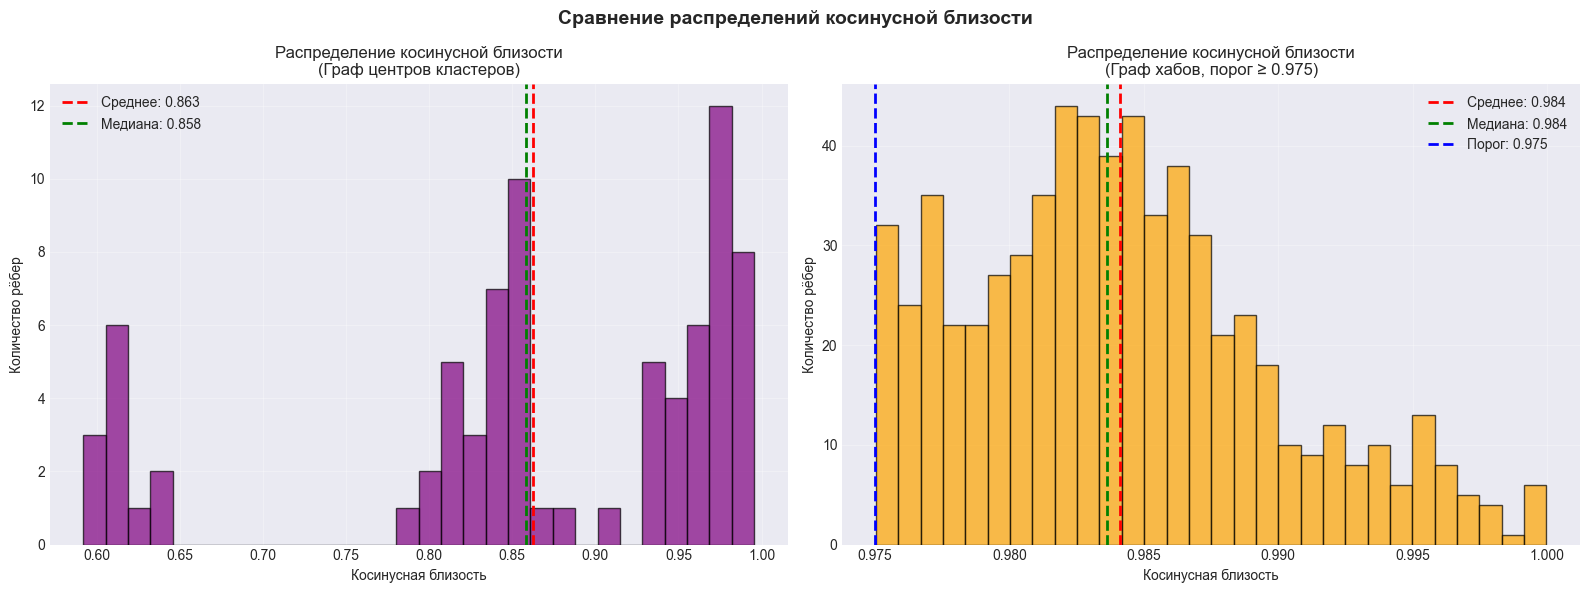

In [97]:
# === Визуализация распределения косинусной близости ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Граф центров кластеров
if edge_cosines_cluster:
    axes[0].hist(edge_cosines_cluster, bins=30, color='purple', edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(edge_cosines_cluster), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(edge_cosines_cluster):.3f}')
    axes[0].axvline(np.median(edge_cosines_cluster), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(edge_cosines_cluster):.3f}')
    axes[0].set_xlabel('Косинусная близость')
    axes[0].set_ylabel('Количество рёбер')
    axes[0].set_title('Распределение косинусной близости\n(Граф центров кластеров)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Граф хабов
if edge_cosines_hub:
    axes[1].hist(edge_cosines_hub, bins=30, color='orange', edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(edge_cosines_hub), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(edge_cosines_hub):.3f}')
    axes[1].axvline(np.median(edge_cosines_hub), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(edge_cosines_hub):.3f}')
    axes[1].axvline(HIGHER_THETA, color='blue', linestyle='--', linewidth=2, label=f'Порог: {HIGHER_THETA}')
    axes[1].set_xlabel('Косинусная близость')
    axes[1].set_ylabel('Количество рёбер')
    axes[1].set_title(f'Распределение косинусной близости\n(Граф хабов, порог ≥ {HIGHER_THETA})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Сравнение распределений косинусной близости', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [98]:
# === Сравнительная статистика ===

print("=" * 70)
print("СРАВНИТЕЛЬНАЯ СТАТИСТИКА ДВУХ ГРАФОВ")
print("=" * 70)

comparison_data = {
    'Метрика': [
        'Количество узлов',
        'Количество рёбер',
        'Плотность графа',
        'Средняя степень узла',
        'Средняя косинусная близость',
        'Медианная косинусная близость',
        'Количество компонент связности'
    ],
    'Граф центров кластеров': [
        G_cluster.number_of_nodes(),
        G_cluster.number_of_edges(),
        f"{nx.density(G_cluster):.4f}",
        f"{sum(dict(G_cluster.degree()).values()) / G_cluster.number_of_nodes():.2f}" if G_cluster.number_of_nodes() > 0 else "0",
        f"{np.mean(edge_cosines_cluster):.4f}" if edge_cosines_cluster else "N/A",
        f"{np.median(edge_cosines_cluster):.4f}" if edge_cosines_cluster else "N/A",
        len(components_cluster)
    ],
    'Граф хабов': [
        G_hub.number_of_nodes(),
        G_hub.number_of_edges(),
        f"{nx.density(G_hub):.4f}",
        f"{sum(dict(G_hub.degree()).values()) / G_hub.number_of_nodes():.2f}" if G_hub.number_of_nodes() > 0 else "0",
        f"{np.mean(edge_cosines_hub):.4f}" if edge_cosines_hub else "N/A",
        f"{np.median(edge_cosines_hub):.4f}" if edge_cosines_hub else "N/A",
        len(components_hub)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print("\n" + "=" * 70)


СРАВНИТЕЛЬНАЯ СТАТИСТИКА ДВУХ ГРАФОВ

                       Метрика Граф центров кластеров Граф хабов
              Количество узлов                     13         84
              Количество рёбер                     78        651
               Плотность графа                 1.0000     0.1867
          Средняя степень узла                  12.00      15.50
   Средняя косинусная близость                 0.8626     0.9841
 Медианная косинусная близость                 0.8580     0.9836
Количество компонент связности                      1          1

